# Named Entity Recognition (NER): From Scratch (HMM + Viterbi) vs. Library (CRF)

### What this notebook covers
This notebook builds a Named Entity Recognition system **twice**:

1. **From scratch (NumPy only):** a Hidden Markov Model (HMM) with Viterbi decoding, trained by counting transition/emission frequencies directly from real tagged data.
2. **Library implementation:** a Conditional Random Field (CRF) using `sklearn-crfsuite`, which uses hand-crafted features and global sequence optimization.

We compare both on **entity-level F1**, visualize tag distributions and confusion patterns, and run hyperparameter experiments on the CRF regularization terms.

### Prerequisites
- Comfortable with Python, NumPy, pandas
- Understands what a sequence labeling task is (vs. plain classification)
- Familiar with BIO tagging conventions (`B-`, `I-`, `O`)
- Basic familiarity with probability (joint vs. conditional) is helpful but not required

### Dataset
**Annotated Corpus for Named Entity Recognition** (GMB corpus, re-tagged), by Abhinav Walia on Kaggle:
🔗 https://www.kaggle.com/datasets/abhinavwalia95/entity-annotated-corpus

- File used: `ner_dataset.csv`
- Columns: `Sentence #`, `Word`, `POS`, `Tag`
- Tags follow the BIO scheme with entity types: `geo`, `org`, `per`, `gpe`, `tim`, `art`, `eve`, `nat`

**Credits:** Dataset curated and shared by Abhinav Walia on Kaggle, derived from the Groningen Meaning Bank (GMB) corpus. All credit for data collection and annotation belongs to the original GMB project and the Kaggle dataset author.

> **Setup note:** Download `ner_dataset.csv` from the Kaggle link above and place it in the same directory as this notebook (or update `DATA_PATH` in Cell 4) before running.


In [8]:
# ===== Core data handling =====
import numpy as np                      # numerical operations, used for the from-scratch HMM (matrices, log-probabilities)
import pandas as pd                      # loading and manipulating the tabular NER dataset

# ===== Visualization =====
import matplotlib.pyplot as plt          # base plotting library
import seaborn as sns                    # statistical visualizations (heatmaps, count plots) built on matplotlib

# ===== Library NER model (CRF) =====
import sklearn_crfsuite                  # Conditional Random Field implementation for sequence labeling
from sklearn_crfsuite import metrics as crf_metrics   # CRF-specific evaluation helpers
from sklearn.model_selection import train_test_split  # splitting sentences into train/test sets
from sklearn.model_selection import cross_val_score   # cross-validation for hyperparameter experiments

# ===== Evaluation =====
from seqeval.metrics import f1_score as seq_f1_score          # entity-level F1 (the CORRECT way to score NER)
from seqeval.metrics import classification_report as seq_report  # detailed entity-level precision/recall/F1 report

# ===== Reproducibility =====
np.random.seed(42)                       # fixes randomness for any sampling/shuffling operations below

# ===== Misc =====
import warnings
warnings.filterwarnings("ignore")        # suppress noisy convergence/deprecation warnings for a clean teaching notebook


## Part 1: Theory Recap

- **NER is sequence labeling, not independent classification** — the label assigned to a word depends on the labels of its neighbors (you can't have `I-PER` immediately after `O`).
- **BIO tagging** encodes entity boundaries directly into per-token labels: `B-` marks the beginning of an entity, `I-` marks a continuation, `O` marks "outside any entity."
- **HMM (generative)** models `P(x, y) = P(y₁) · ∏ P(yₜ|yₜ₋₁) · ∏ P(xₜ|yₜ)` — it assumes each word is generated *from* its hidden tag, and tags form a Markov chain.
- **CRF (discriminative)** models `P(y|x)` directly using global normalization over the whole sequence, allowing richer, overlapping features (capitalization, suffixes, POS) without the independence assumptions an HMM makes.
- **Viterbi decoding** finds the single best-scoring tag sequence efficiently via dynamic programming, instead of checking every possible sequence (which would be exponential).


## Loading the Real-World Dataset

We load `ner_dataset.csv` directly — no synthetic or generated data is used anywhere in this notebook.

- **Features used:** `Word` (the token text) and `POS` (its part-of-speech tag) — both used as inputs to derive emission/feature information.
- **Target variable:** `Tag` — the BIO-encoded named entity tag for each token (e.g., `B-per`, `I-org`, `O`).
- `Sentence #` groups tokens into sentences; this grouping is essential because NER operates over sequences, not isolated words.

We inspect `head()`, `info()`, and `describe()` to understand structure, data types, and the prevalence of missing values before doing anything else.


In [9]:
# Load the real Kaggle dataset.
# NOTE: this file is NOT UTF-8 encoded; Kaggle's GMB-derived CSV requires 'unicode_escape'
# to correctly parse raw escaped characters without throwing a UnicodeDecodeError.
DATA_PATH = "ner_dataset.csv"

df_raw = pd.read_csv(DATA_PATH, encoding="unicode_escape")

print("Shape:", df_raw.shape)
display(df_raw.head(10))
print("\n--- df.info() ---")
df_raw.info()
print("\n--- df.describe() (categorical summary) ---")
display(df_raw.describe(include="all"))


Shape: (1048575, 4)


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,NaN,of,IN,O
2,NaN,demonstrators,NNS,O
3,NaN,have,VBP,O
4,NaN,marched,VBN,O
5,NaN,through,IN,O
6,NaN,London,NNP,B-geo
7,NaN,to,TO,O
8,NaN,protest,VB,O
9,NaN,the,DT,O



--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Sentence #  47959 non-null    str  
 1   Word        1048565 non-null  str  
 2   POS         1048575 non-null  str  
 3   Tag         1048575 non-null  str  
dtypes: str(4)
memory usage: 41.6 MB

--- df.describe() (categorical summary) ---


,Sentence #,Word,POS,Tag
count,47959,1048565,1048575,1048575
unique,47959,35177,42,17
top,Sentence: 1,the,NN,O
freq,1,52573,145807,887908


## Preprocessing

Steps performed below:

1. **Handle nulls:** `Sentence #` is only populated on the first word of each sentence in the raw file (a Kaggle quirk) — we forward-fill it so every row knows which sentence it belongs to.
2. **Group into sequences:** sentences are reconstructed as lists of `(word, pos, tag)` tuples, since NER models operate on whole sequences, not single rows.
3. **Encode categoricals:** words and tags are mapped to integer indices for the from-scratch HMM (which needs numeric matrix indices, not strings).
4. **No numeric scaling needed:** unlike continuous-feature ML problems, NER inputs here are categorical tokens — there are no continuous features to standardize.


In [10]:
# 1. Forward-fill Sentence # so every token row is tagged with its sentence id
df = df_raw.copy()
df["Sentence #"] = df["Sentence #"].ffill()

# Drop any remaining fully-null rows (rare malformed lines in the raw CSV)
df = df.dropna(subset=["Word", "Tag"])

# 2. Reconstruct sentences as sequences of (word, pos, tag)
sentences = (
    df.groupby("Sentence #")
      .apply(lambda s: list(zip(s["Word"], s["POS"], s["Tag"])))
      .tolist()
)
print(f"Total sentences reconstructed: {len(sentences)}")
print("Example sentence (word, POS, tag):")
print(sentences[0])

# 3. Build categorical vocabularies (word -> id, tag -> id) for the from-scratch HMM
all_words = sorted(set(df["Word"]))
all_tags  = sorted(set(df["Tag"]))

word2idx = {w: i for i, w in enumerate(all_words)}
tag2idx  = {t: i for i, t in enumerate(all_tags)}
idx2tag  = {i: t for t, i in tag2idx.items()}

# Reserve an index for unseen words at test time (out-of-vocabulary handling)
UNK_IDX = len(word2idx)

print(f"\nVocabulary size (words): {len(word2idx)}")
print(f"Number of unique tags: {len(all_tags)}")
print(f"Tags: {all_tags}")

# 4. Train/test split at the SENTENCE level (not the token level) to avoid leaking
#    tokens from the same sentence into both train and test sets.
train_sents, test_sents = train_test_split(sentences, test_size=0.2, random_state=42)
print(f"\nTrain sentences: {len(train_sents)} | Test sentences: {len(test_sents)}")


Total sentences reconstructed: 47959
Example sentence (word, POS, tag):
[('Thousands', 'NNS', 'O'), ('of', 'IN', 'O'), ('demonstrators', 'NNS', 'O'), ('have', 'VBP', 'O'), ('marched', 'VBN', 'O'), ('through', 'IN', 'O'), ('London', 'NNP', 'B-geo'), ('to', 'TO', 'O'), ('protest', 'VB', 'O'), ('the', 'DT', 'O'), ('war', 'NN', 'O'), ('in', 'IN', 'O'), ('Iraq', 'NNP', 'B-geo'), ('and', 'CC', 'O'), ('demand', 'VB', 'O'), ('the', 'DT', 'O'), ('withdrawal', 'NN', 'O'), ('of', 'IN', 'O'), ('British', 'JJ', 'B-gpe'), ('troops', 'NNS', 'O'), ('from', 'IN', 'O'), ('that', 'DT', 'O'), ('country', 'NN', 'O'), ('.', '.', 'O')]

Vocabulary size (words): 35177
Number of unique tags: 17
Tags: ['B-art', 'B-eve', 'B-geo', 'B-gpe', 'B-nat', 'B-org', 'B-per', 'B-tim', 'I-art', 'I-eve', 'I-geo', 'I-gpe', 'I-nat', 'I-org', 'I-per', 'I-tim', 'O']

Train sentences: 38367 | Test sentences: 9592


## Part 2: From Scratch Implementation

We implement a **Hidden Markov Model (HMM) NER tagger with Viterbi decoding**, using only NumPy.

**Why an HMM for "from scratch"?** A linear-chain CRF's training requires gradient-based optimization of a global log-likelihood (forward-backward + gradient descent), which is heavy to implement cleanly in a teaching notebook. An HMM, by contrast, has **closed-form parameter estimation** (just counting frequencies) while still requiring the same core inference mechanism — **Viterbi decoding** — that powers CRFs and BiLSTM-CRFs in production. This lets us implement the *exact same decoding algorithm* used in industry-grade sequence taggers, while keeping training simple enough to write transparently in NumPy.

We build a class `HMMTagger` with:
- `fit()` — estimates initial, transition, and emission probabilities by counting from training sequences.
- `predict()` — runs the Viterbi algorithm on new sentences to find the most likely tag sequence.


In [11]:
class HMMTagger:
    """
    A Hidden Markov Model for sequence tagging, trained via frequency counting
    and decoded via the Viterbi algorithm. Pure NumPy implementation.
    """

    def __init__(self, tags, words, unk_idx, smoothing=1e-6):
        self.tags = tags                          # list of all possible tags
        self.n_tags = len(tags)
        self.tag2idx = {t: i for i, t in enumerate(tags)}
        self.words = words                        # vocabulary (training words)
        self.word2idx = {w: i for i, w in enumerate(words)}
        self.unk_idx = unk_idx                     # index reserved for unseen words
        self.smoothing = smoothing                 # additive smoothing to avoid zero-probabilities (INTERVIEW NOTE: handles unseen transitions/emissions gracefully)

    def fit(self, tagged_sentences):
        """
        Estimate HMM parameters by counting from labeled sequences:
        - initial_probs[i]      = P(tag_i is the first tag in a sentence)
        - transition_probs[i,j] = P(tag_j | tag_i)   -- INTERVIEW NOTE: this is the Markov assumption in action
        - emission_probs[i,w]   = P(word_w | tag_i)
        All stored in LOG SPACE to prevent numerical underflow over long sequences.
        """
        n_tags = self.n_tags
        n_words = len(self.words) + 1  # +1 for the UNK bucket

        init_counts = np.full(n_tags, self.smoothing)           # smoothing avoids hard zero log-probabilities
        trans_counts = np.full((n_tags, n_tags), self.smoothing)
        emit_counts = np.full((n_tags, n_words), self.smoothing)

        for sent in tagged_sentences:
            prev_tag_idx = None
            for word, pos, tag in sent:
                tag_idx = self.tag2idx[tag]
                word_idx = self.word2idx.get(word, self.unk_idx)

                emit_counts[tag_idx, word_idx] += 1              # count this (tag -> word) emission

                if prev_tag_idx is None:
                    init_counts[tag_idx] += 1                     # this tag started a sentence
                else:
                    trans_counts[prev_tag_idx, tag_idx] += 1      # count this (prev_tag -> tag) transition

                prev_tag_idx = tag_idx

        # Normalize counts into probabilities, then convert to log-space
        # INTERVIEW NOTE: log-space addition replaces probability multiplication -> avoids underflow on long sentences
        self.log_init = np.log(init_counts / init_counts.sum())
        self.log_trans = np.log(trans_counts / trans_counts.sum(axis=1, keepdims=True))
        self.log_emit = np.log(emit_counts / emit_counts.sum(axis=1, keepdims=True))
        return self

    def _viterbi(self, words):
        """
        Core decoding step: finds the single highest-probability tag sequence
        for a given list of words using dynamic programming (Viterbi algorithm).
        """
        T = len(words)
        n_tags = self.n_tags

        # delta[t, j] = best log-probability of any tag sequence ending in tag j at position t
        delta = np.zeros((T, n_tags))
        # backpointer[t, j] = which previous tag state led to the best score at (t, j)
        backpointer = np.zeros((T, n_tags), dtype=int)

        word_idx0 = self.word2idx.get(words[0], self.unk_idx)
        delta[0] = self.log_init + self.log_emit[:, word_idx0]   # base case: initial tag probs + first emission

        for t in range(1, T):
            word_idx = self.word2idx.get(words[t], self.unk_idx)
            for j in range(n_tags):
                # INTERVIEW NOTE: this line IS the Viterbi recursion --
                # max over all previous tags i of (best score so far + transition score), then add emission
                scores = delta[t - 1] + self.log_trans[:, j]
                backpointer[t, j] = np.argmax(scores)
                delta[t, j] = np.max(scores) + self.log_emit[j, word_idx]

        # Backtrack from the best final state to recover the full best path
        best_path = np.zeros(T, dtype=int)
        best_path[-1] = np.argmax(delta[-1])
        for t in range(T - 2, -1, -1):
            best_path[t] = backpointer[t + 1, best_path[t + 1]]

        return [self.tags[i] for i in best_path]

    def predict(self, sentences_words):
        """Predict tag sequences for a list of word-sequences (sentences)."""
        return [self._viterbi(words) for words in sentences_words]


In [12]:
# Fit the from-scratch HMM on the training sentences
hmm_model = HMMTagger(tags=all_tags, words=all_words, unk_idx=UNK_IDX)
hmm_model.fit(train_sents)

# Prepare test inputs (words only) and gold labels (tags only)
test_words = [[w for w, p, t in sent] for sent in test_sents]
test_gold_tags = [[t for w, p, t in sent] for sent in test_sents]

# Predict using Viterbi decoding
hmm_pred_tags = hmm_model.predict(test_words)

# Evaluate using ENTITY-LEVEL F1 (seqeval) -- the correct metric for NER, not token accuracy
hmm_f1 = seq_f1_score(test_gold_tags, hmm_pred_tags)
print(f"From-Scratch HMM — Entity-level F1 score: {hmm_f1:.4f}\n")
print("Detailed entity-level report (From-Scratch HMM):")
print(seq_report(test_gold_tags, hmm_pred_tags))


From-Scratch HMM — Entity-level F1 score: 0.7737

Detailed entity-level report (From-Scratch HMM):
              precision    recall  f1-score   support

         art       0.12      0.13      0.12        94
         eve       0.22      0.40      0.28        70
         geo       0.82      0.87      0.84      7558
         gpe       0.88      0.91      0.89      3142
         nat       0.05      0.38      0.09        40
         org       0.67      0.59      0.63      4151
         per       0.75      0.68      0.71      3400
         tim       0.84      0.75      0.80      4077

   micro avg       0.78      0.77      0.77     22532
   macro avg       0.54      0.59      0.55     22532
weighted avg       0.79      0.77      0.78     22532



## Part 3: Sklearn (CRF) Implementation

`sklearn-crfsuite` implements a **linear-chain Conditional Random Field**, which differs from our from-scratch HMM in important ways:

- **Discriminative, not generative:** it models `P(y|x)` directly instead of modeling how words are "generated" from tags — this generally yields better accuracy because it isn't forced into the HMM's independence assumptions.
- **Rich, overlapping features:** we can feed it arbitrary features per token (capitalization, prefixes/suffixes, neighboring words, POS tags) — an HMM can only use the current word as the emission feature.
- **Global optimization:** parameters are learned by maximizing the *log-likelihood of the entire sequence* via gradient-based methods (L-BFGS), rather than simple frequency counting.

We extract a small, interpretable feature set per token and train the CRF, then compare directly against the HMM's entity-level F1.


In [7]:
def word_features(sent, i):
    """Extract a feature dictionary for the i-th word in a (word, pos, tag) sentence."""
    word = sent[i][0]
    pos = sent[i][1]
    features = {
        "bias": 1.0,
        "word.lower()": word.lower(),
        "word.isupper()": word.isupper(),
        "word.istitle()": word.istitle(),
        "word.isdigit()": word.isdigit(),
        "word[-3:]": word[-3:],          # suffix -- helpful for catching plural/possessive entity patterns
        "postag": pos,
    }
    if i > 0:
        prev_word = sent[i - 1][0]
        features.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:word.istitle()": prev_word.istitle(),
        })
    else:
        features["BOS"] = True            # beginning-of-sentence marker

    if i < len(sent) - 1:
        next_word = sent[i + 1][0]
        features.update({
            "+1:word.lower()": next_word.lower(),
            "+1:word.istitle()": next_word.istitle(),
        })
    else:
        features["EOS"] = True            # end-of-sentence marker

    return features

def sent_to_features(sent):
    return [word_features(sent, i) for i in range(len(sent))]

def sent_to_labels(sent):
    return [tag for word, pos, tag in sent]

# Build feature/label sequences for train and test sets
X_train = [sent_to_features(s) for s in train_sents]
y_train = [sent_to_labels(s) for s in train_sents]
X_test = [sent_to_features(s) for s in test_sents]
y_test = [sent_to_labels(s) for s in test_sents]

# Train the CRF
crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",         # L-BFGS optimizer for the log-likelihood objective
    c1=0.1,                    # L1 regularization strength
    c2=0.1,                    # L2 regularization strength
    max_iterations=100,
    all_possible_transitions=True   # allows the model to score even unseen tag transitions (smoothed)
)
crf.fit(X_train, y_train)

# Predict and evaluate
crf_pred = crf.predict(X_test)
crf_f1 = seq_f1_score(y_test, crf_pred)

print(f"Sklearn CRF — Entity-level F1 score: {crf_f1:.4f}\n")
print("Detailed entity-level report (Sklearn CRF):")
print(seq_report(y_test, crf_pred))

print("\n=== Direct Comparison ===")
print(f"From-Scratch HMM F1 : {hmm_f1:.4f}")
print(f"Sklearn CRF F1      : {crf_f1:.4f}")


Sklearn CRF — Entity-level F1 score: 0.8493

Detailed entity-level report (Sklearn CRF):
              precision    recall  f1-score   support

         art       0.29      0.10      0.14        94
         eve       0.56      0.33      0.41        70
         geo       0.85      0.91      0.88      7558
         gpe       0.97      0.94      0.95      3142
         nat       0.48      0.28      0.35        40
         org       0.79      0.70      0.74      4151
         per       0.79      0.78      0.79      3400
         tim       0.90      0.86      0.88      4077

   micro avg       0.86      0.84      0.85     22532
   macro avg       0.71      0.61      0.64     22532
weighted avg       0.85      0.84      0.85     22532


=== Direct Comparison ===
From-Scratch HMM F1 : 0.7737
Sklearn CRF F1      : 0.8493


### Visualizations

Two plots that build intuition about the dataset and model behavior:

1. **Entity tag frequency distribution** — shows the severe class imbalance (the `O` tag dominates), which explains why token accuracy is a misleading metric for NER.
2. **Model comparison bar chart** — entity-level F1 of the from-scratch HMM vs. the sklearn CRF, side by side.


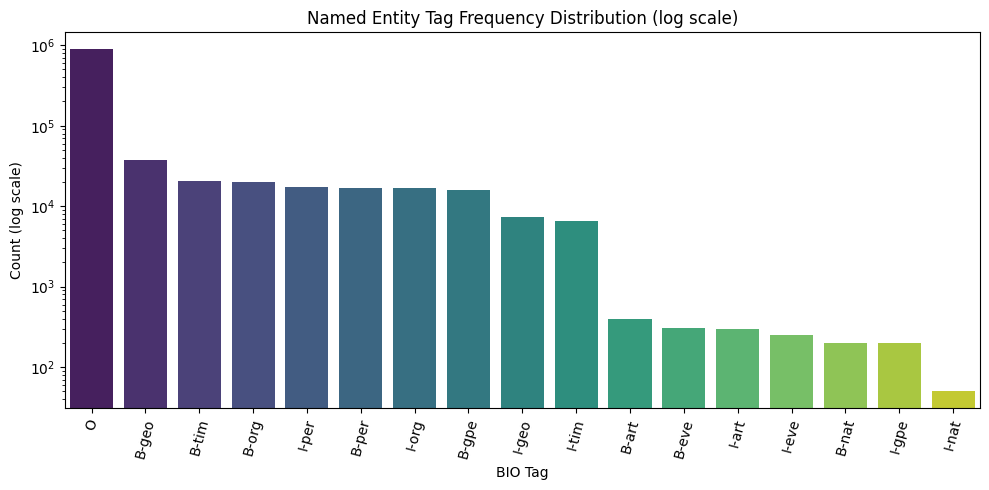

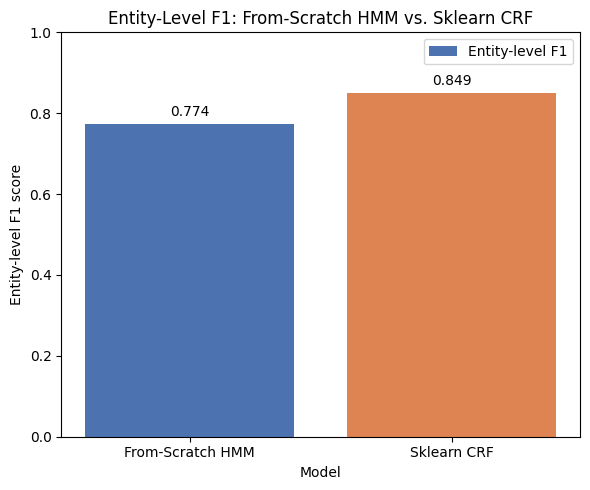

In [13]:
# Plot 1: Tag frequency distribution (log scale due to heavy "O" imbalance)
plt.figure(figsize=(10, 5))
tag_counts = df["Tag"].value_counts()
sns.barplot(x=tag_counts.index, y=tag_counts.values, palette="viridis")
plt.yscale("log")
plt.title("Named Entity Tag Frequency Distribution (log scale)")
plt.xlabel("BIO Tag")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Plot 2: Model comparison -- From-Scratch HMM vs Sklearn CRF
plt.figure(figsize=(6, 5))
model_names = ["From-Scratch HMM", "Sklearn CRF"]
f1_scores = [hmm_f1, crf_f1]
bars = plt.bar(model_names, f1_scores, color=["#4C72B0", "#DD8452"], label="Entity-level F1")
plt.ylim(0, 1)
plt.title("Entity-Level F1: From-Scratch HMM vs. Sklearn CRF")
plt.xlabel("Model")
plt.ylabel("Entity-level F1 score")
plt.legend()
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.3f}", ha="center")
plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

For the **CRF**, the two hyperparameters that matter most are:

- **`c1` (L1 regularization):** higher values push more feature weights to exactly zero, producing a sparser, more interpretable model — but too high causes underfitting.
- **`c2` (L2 regularization):** higher values shrink all feature weights smoothly, controlling overfitting without zeroing them out — too high also causes underfitting.

We vary both and observe their effect on entity-level F1 using a smaller cross-validation loop (a full grid search over the entire dataset would be slow in a teaching notebook, so we use a representative subset of sentences for speed).


c1=0.01  -> Entity F1: 0.7725
c1=0.1   -> Entity F1: 0.7666
c1=0.5   -> Entity F1: 0.7578
c1=1.0   -> Entity F1: 0.7454

c2=0.01  -> Entity F1: 0.7554
c2=0.1   -> Entity F1: 0.7666
c2=0.5   -> Entity F1: 0.7697
c2=1.0   -> Entity F1: 0.7612


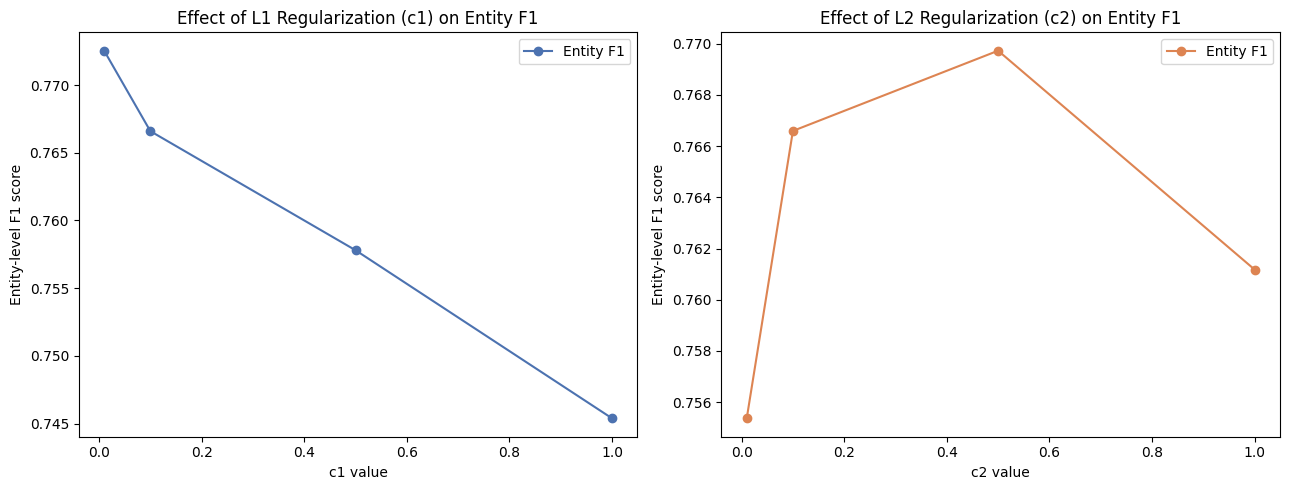

In [14]:
# Use a representative subset of training sentences for faster CV experimentation
subset_size = min(800, len(train_sents))
subset_idx = np.random.RandomState(42).choice(len(train_sents), size=subset_size, replace=False)
X_subset = [X_train[i] for i in subset_idx]
y_subset = [y_train[i] for i in subset_idx]

c1_values = [0.01, 0.1, 0.5, 1.0]
c2_values = [0.01, 0.1, 0.5, 1.0]

c1_f1_scores = []
for c1_val in c1_values:
    model = sklearn_crfsuite.CRF(algorithm="lbfgs", c1=c1_val, c2=0.1,
                                  max_iterations=50, all_possible_transitions=True)
    model.fit(X_subset, y_subset)
    preds = model.predict(X_test[:200])           # evaluate on a fixed test slice for speed
    score = seq_f1_score(y_test[:200], preds)
    c1_f1_scores.append(score)
    print(f"c1={c1_val:<5} -> Entity F1: {score:.4f}")

print()
c2_f1_scores = []
for c2_val in c2_values:
    model = sklearn_crfsuite.CRF(algorithm="lbfgs", c1=0.1, c2=c2_val,
                                  max_iterations=50, all_possible_transitions=True)
    model.fit(X_subset, y_subset)
    preds = model.predict(X_test[:200])
    score = seq_f1_score(y_test[:200], preds)
    c2_f1_scores.append(score)
    print(f"c2={c2_val:<5} -> Entity F1: {score:.4f}")

# Plot the effect of each hyperparameter on F1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(c1_values, c1_f1_scores, marker="o", color="#4C72B0", label="Entity F1")
axes[0].set_title("Effect of L1 Regularization (c1) on Entity F1")
axes[0].set_xlabel("c1 value")
axes[0].set_ylabel("Entity-level F1 score")
axes[0].legend()

axes[1].plot(c2_values, c2_f1_scores, marker="o", color="#DD8452", label="Entity F1")
axes[1].set_title("Effect of L2 Regularization (c2) on Entity F1")
axes[1].set_xlabel("c2 value")
axes[1].set_ylabel("Entity-level F1 score")
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 5: Interview Corner

**Most important conceptual question:** *"Your NER model has 95% token-level accuracy, but the product team says quality is poor in production. What's wrong, and how should you actually be evaluating this model?"*

Here's how to walk through it narratively in an interview:

1. **Start by questioning the metric, not the model.** In NER, the `O` tag (outside any entity) usually accounts for 80–95% of all tokens. A model that predicts `O` for *everything* would already score extremely high on token-level accuracy, despite being completely useless for extracting entities.
2. **Explain why entity-level evaluation is different.** A predicted entity only counts as correct if **both** the span boundaries and the entity type match the gold label exactly — partial credit isn't given for getting the type right but missing a word at the boundary (e.g., tagging "Bank of America" as just "America").
3. **Connect it back to the math.** Token accuracy treats every token as an independent classification decision. Entity-level F1 respects the *structured* nature of the task — which is exactly why we use CRFs/Viterbi decoding in the first place, instead of independent per-token softmax.
4. **Give the fix.** Recommend switching all reporting to entity-level Precision/Recall/F1 (via `seqeval`), and consider a confusion analysis specifically on the *non-O* tags to see where the real boundary or type errors are concentrated.
5. **Bonus depth (senior-level signal):** mention that this exact same "metric mismatch" pattern shows up in other structured prediction tasks too — e.g., pixel accuracy vs. IoU in object detection, or word-level vs. BLEU-style metrics in translation. Recognizing the general pattern (aggregate metrics hiding structural failure) signals strong engineering judgment, not just topic-specific memorization.


## Key Takeaways

- **NER is structured prediction, not independent classification** — adjacent label dependencies matter, which is why Viterbi/CRF-style decoding outperforms naive per-token softmax.
- **Always evaluate with entity-level F1, never token-level accuracy** — the `O` tag's dominance makes accuracy a misleading and dangerously optimistic metric.
- **HMMs and CRFs share the same decoding backbone (Viterbi)** but differ fundamentally in training: HMMs are generative and counted, CRFs are discriminative and optimized — CRFs generally win because they support rich overlapping features.
- **Feature engineering still matters even in classic CRF pipelines** — capitalization, suffixes, and neighboring-word context meaningfully boost performance without any neural network.
- **Regularization (c1/c2 in CRF) trades off sparsity/smoothness vs. underfitting** — tuning them is a quick, cheap way to materially move entity-level F1 before reaching for a bigger model.
